In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


from credit_default.utils import get_models_and_routes
from credit_default.evaluation import (
    score_modelo_lineal,
    score_modelo_no_lineal,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve
)

from credit_default.features import (
    load_checkpoint
)

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn import model_selection

import matplotlib.pyplot as plt

In [ ]:
nombre_checkpoint = 'vif_checkpoint'
checkpoints_path = PROJECT_ROOT / 'checkpoints' / nombre_checkpoint

arreglo_frames, json_loaded = load_checkpoint(checkpoints_path)
model_list, lista_nombres = get_models_and_routes()
numero_modelos = len(model_list)

X_train, X_test, y_train, y_test = arreglo_frames

Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/X_train.parquet
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/X_test.parquet
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/y_train.parquet
Aplanando y_train
Cargando el archivo /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/checkpoints/vif_checkpoint/y_test.parquet
Aplanando y_test
Preparando modelos ... /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit
Leyendo la ruta /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit/models/logistic_np1log/lr_np1log.joblib
Modelo cargado lr_np1log.joblib.
Leyendo la ruta /Users/marcoantoniogarciamartinez/Documents/Python Local/Proyectos/DefaultUCICredit

In [3]:
model_np1log = model_list[0]
model_xgb = model_list[1]
model_raw = model_list[2]

In [7]:
modelos_listado = ['reg_np1log', 'xgboost', 'reg_baseline']
i = 0

modelos_rendimiento = {}

for model in model_list:

    y_pred = model.predict(X_train)  ## modificado, antes X_test
    y_probas = model.predict_proba(X_train)[:, 1]  #scores para rocauc prauc
    CM, F1, ACCURACY, ROCAUC, RECALL, PRECISION, PR_AUC = score_modelo_no_lineal(y_train, y_pred, y_probas)
    data = {
        'CM' : CM,
        'F1' : F1,
        'ACCURACY' : ACCURACY,
        'PRECISION' : PRECISION,
        'ROCAUC' : ROCAUC,
        'RECALL' : RECALL,
        'PR_AUC' : PR_AUC,
        'Y_TRUE' : y_train,
        'Y_PRED' : y_pred, ## Se mantiene
        'SCORES' : y_probas
    }
    modelos_rendimiento[modelos_listado[i]] = data
    i += 1


In [8]:
frame = pd.DataFrame(modelos_rendimiento)

frame = frame.drop(['CM','SCORES', 'Y_TRUE', 'Y_PRED'],)

frame

,reg_np1log,xgboost,reg_baseline
F1,0.540811,0.499148,0.538408
ACCURACY,0.781891,0.828498,0.779556
PRECISION,0.506327,0.70568,0.501708
ROCAUC,0.771021,0.80976,0.775279
RECALL,0.580335,0.386137,0.5809
PR_AUC,0.543181,0.607642,0.545127


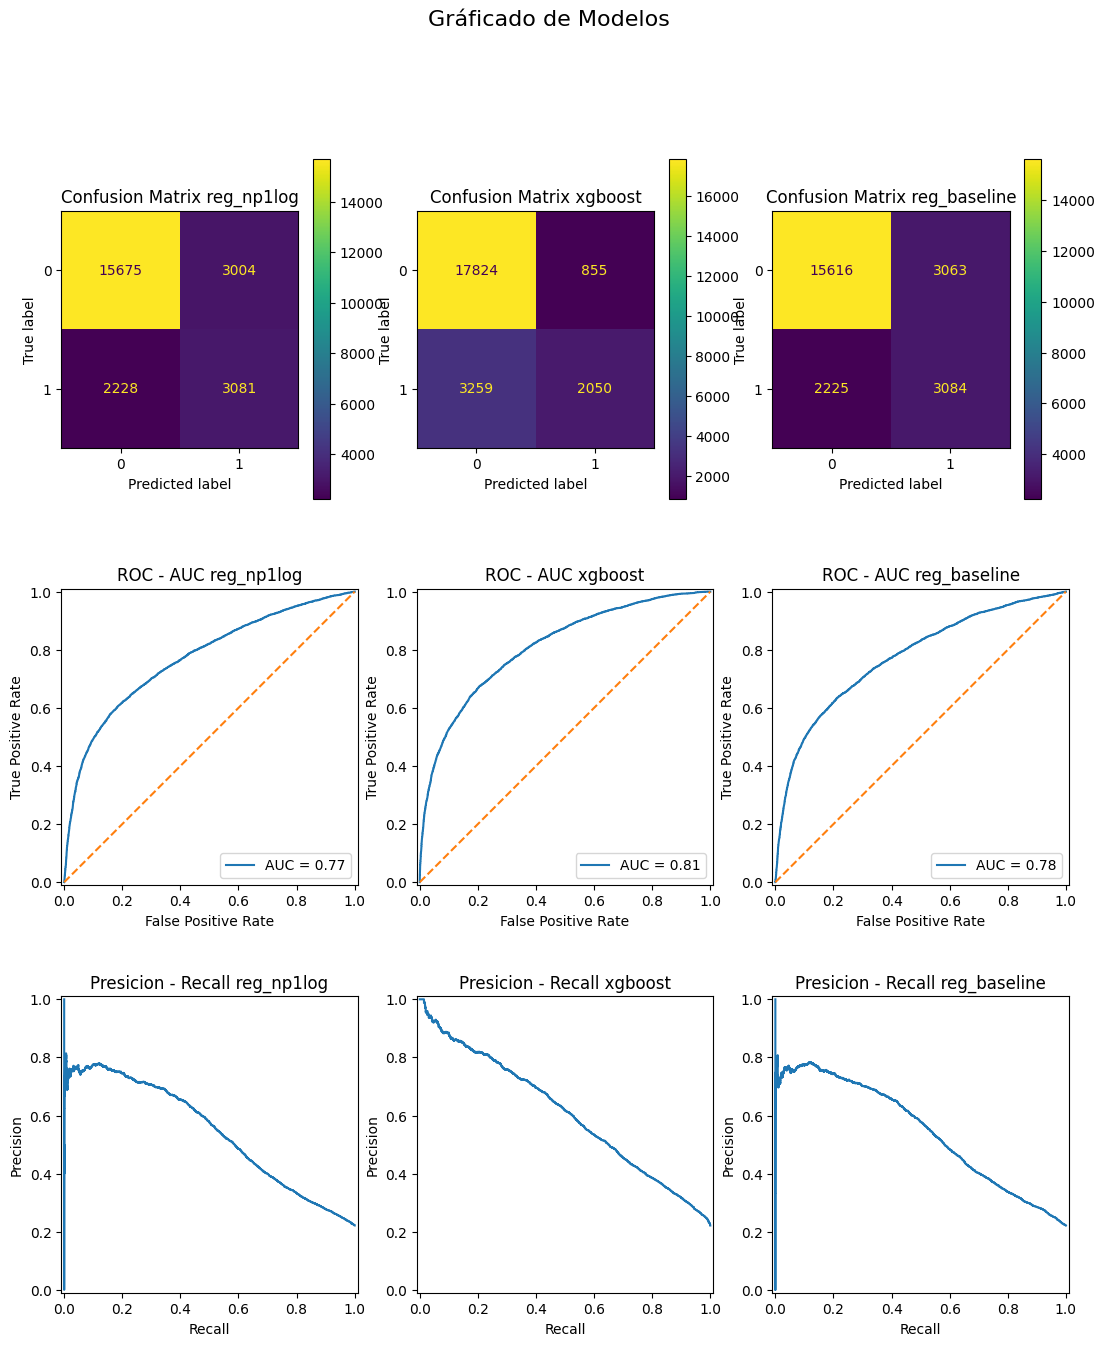

In [9]:
## Ploting

filas = 3
columnas = 3

fig, axes = plt.subplots(filas, columnas, figsize = (13,15))

columna_index = 0
fila = 0

for nombre_modelo, calificaciones in modelos_rendimiento.items():
    
    plot_confusion_matrix(calificaciones['CM'], axes = axes[columna_index, fila])
    axes[columna_index, fila].set_title(f'Confusion Matrix {nombre_modelo}')

    plot_roc_curve(calificaciones['Y_TRUE'], calificaciones['SCORES'], axes = axes[1, fila])
    axes[1, fila].set_title(f'ROC - AUC {nombre_modelo}')

    plot_precision_recall_curve(calificaciones['Y_TRUE'], calificaciones['SCORES'], axes = axes[2, fila])
    axes[2, fila].set_title(f'Presicion - Recall {nombre_modelo}')

    fila += 1



fig.suptitle('Gráficado de Modelos', fontsize = 16)
plt.show()

Text(0.5, 1.0, 'RECALL de los modelos')

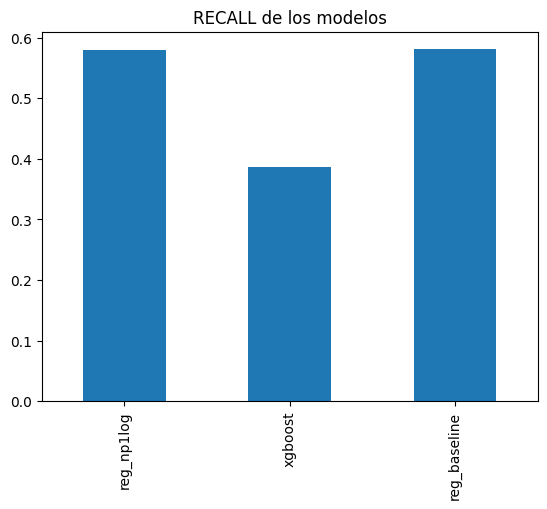

In [10]:
frame.T['RECALL'].plot(kind = 'bar')
plt.title('RECALL de los modelos')

## Thresholds

Para un problema como lo es el de credit. Necesitamos valorar que, negocio busca minimizar Falsos Negativos ya que asumiremos que les cuesta 500 unidades de perdida, mientras que cada cliente pagador otorga un beneficio de 200, mientras que la adquisicion de clientes es de 100 unidades.

No es matemática dura ni busca ser referencia, pero puede ejemplificar perfectamente el fenomeno de optimizar para negocio mas alla de solo valorar f1 score o el area por debajo de la curva ROC.

In [11]:

macro_model = [] ## Aqui almacenamos cada tipo de modelo

 ## Aqui almacenaos resutlados por thresholds

thresholds_train = np.arange(0.1, 0.9, 0.1)

In [ ]:
macro_model = []
thresholds_train = np.arange(0.1, 0.9, 0.05)
j = 0

cv = model_selection.StratifiedKFold(
    n_splits = 10,
    shuffle = True,
    random_state = 42
)

for model in model_list:

    modelos_rendimiento_thresholds = {}

    y_probas_oof = model_selection.cross_val_predict(
        model,
        X_train,
        y_train,
        cv = cv,
        method = 'predict_proba'
    )[:, 1]

    for threshold in thresholds_train:

        y_pred_off = (y_probas_oof >= threshold).astype(int)

        CM, F1, ACCURACY, ROCAUC, RECALL, PRECISION, PR_AUC = score_modelo_no_lineal(y_train, y_pred_off, y_probas_oof)
        data = {
            'THRESHOLD' : threshold,
            'F1' : F1,
            'ACCURACY' : ACCURACY,
            'PRECISION' : PRECISION,
            'ROCAUC' : ROCAUC,
            'RECALL' : RECALL,
            'PR_AUC' : PR_AUC,
        }
        print(f'Almacenando {modelos_listado[j]} - {threshold:.2f}')
        modelos_rendimiento_thresholds[modelos_listado[j] + f'_{threshold}'] = data
    
    macro_model.append(modelos_rendimiento_thresholds)
    j+= 1

Almacenando reg_np1log - 0.1
Almacenando reg_np1log - 0.15000000000000002
Almacenando reg_np1log - 0.20000000000000004
Almacenando reg_np1log - 0.25000000000000006
Almacenando reg_np1log - 0.30000000000000004
Almacenando reg_np1log - 0.3500000000000001
Almacenando reg_np1log - 0.40000000000000013
Almacenando reg_np1log - 0.4500000000000001
Almacenando reg_np1log - 0.5000000000000001
Almacenando reg_np1log - 0.5500000000000002
Almacenando reg_np1log - 0.6000000000000002
Almacenando reg_np1log - 0.6500000000000001
Almacenando reg_np1log - 0.7000000000000002
Almacenando reg_np1log - 0.7500000000000002
Almacenando reg_np1log - 0.8000000000000003
Almacenando reg_np1log - 0.8500000000000003
Almacenando xgboost - 0.1
Almacenando xgboost - 0.15000000000000002
Almacenando xgboost - 0.20000000000000004
Almacenando xgboost - 0.25000000000000006
Almacenando xgboost - 0.30000000000000004
Almacenando xgboost - 0.3500000000000001
Almacenando xgboost - 0.40000000000000013
Almacenando xgboost - 0.45000

In [19]:
dataframes = []

for modelo in macro_model:
    nombres  = [nombre for nombre in modelo.keys()]
    modelo_reg = pd.DataFrame(modelo).T.reset_index().drop(columns = 'index')
    dataframes.append(modelo_reg)

In [42]:
for indice in range(0, len(lista_nombres)):
    nombre_modelo_frame = lista_nombres[indice]
    print(f'Mostrando los scores por threshold de {nombre_modelo_frame}')
    framing_view = dataframes[indice]
    print(framing_view)

Mostrando los scores por threshold de lr_np1log.joblib
    THRESHOLD        F1  ACCURACY  PRECISION    ROCAUC    RECALL    PR_AUC
0        0.10  0.362679  0.222611   0.221536  0.767663  0.999435  0.536837
1        0.15  0.364852  0.231616   0.223272  0.767663  0.997175  0.536837
2        0.20  0.371576  0.259713   0.228768  0.767663  0.988887  0.536837
3        0.25  0.387314  0.324329   0.242279  0.767663  0.964965  0.536837
4        0.30  0.417017  0.432716   0.269894  0.767663  0.916745  0.536837
5        0.35  0.455674  0.566658   0.315564  0.767663  0.819552  0.536837
6        0.40  0.500827  0.685551   0.386044  0.767663  0.712752  0.536837
7        0.45  0.524169  0.748041   0.450291  0.767663  0.627048  0.536837
8        0.50  0.538306  0.780682   0.503943  0.767663  0.577698  0.536837
9        0.55  0.536102  0.795106   0.537268  0.767663  0.534941  0.536837
10       0.60  0.532171  0.807529   0.575877  0.767663  0.494632  0.536837
11       0.65  0.518543  0.815449   0.613484 

## Conclusión importante

En este caso particular donde asumimos que optimizar Recall es vital para reducir Falsos Negativos, buscamos un buen threshold que no sacrifique mucha Precision del modelo.

Por lo que para el CrossValidation resulta crucial elegir:

np1log a .55
xgboost a .30

Se descarta el modelo raw.

## Nota

El siguiente código muestra un analisis para el threshold al 50% que es el default del fit de scikit learn, pero como hemos analizado anteriormente, no es exactamente bueno ni malo, sino que depende del problema, a continuación muestro una versión tradicional.

In [27]:
resultados = []
names = []
scoring = 'recall'
i = 0

for modelo in model_list:

    kfold = model_selection.StratifiedKFold( ## MUY importante dada el balance de clase
        n_splits = 10,
        shuffle = True,
        random_state = 42
    )
    
    cv_results = model_selection.cross_val_score(
        modelo,
        X_train, y_train,
        cv = kfold,
        scoring = scoring
    )

    resultados.append(cv_results)
    names.append(lista_nombres[i])
    msg = f'{lista_nombres[i]} - {cv_results.mean()} - {cv_results.std()}'
    print(msg)
    i+=1

lr_np1log.joblib - 0.5777052908360871 - 0.02395627644473292
xgboost_base.joblib - 0.37239384571651923 - 0.023332048081655746
lr_raw.joblib - 0.579023913584195 - 0.023041246627576884


Text(0.5, 1.0, 'Resultados del Cross Validation con scoring (f1)')

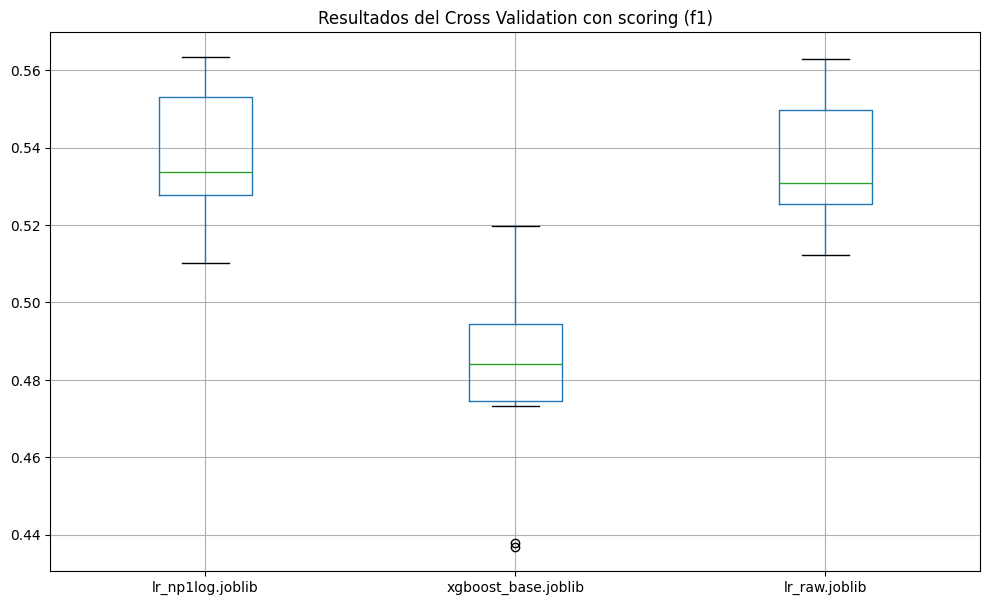

In [26]:
plt.figure(figsize = (12, 7))

resultados_df = pd.DataFrame(resultados, index = names).T
resultados_df.boxplot()
plt.title(f'Resultados del Cross Validation con scoring ({scoring})')

In [ ]:
## Experimental, importando skmetrics

from sklearn.base import clone
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)
from scipy.stats import ttest_rel, wilcoxon

cv = model_selection.StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

candidatos = {
    "xgboost_t030": {
        "model": model_xgb,
        "threshold": 0.30
    },
    "lr_np1log_t050": {
        "model": model_np1log,
        "threshold": 0.50
    }
}

resultados_fold = []

for fold_id, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

    X_tr_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_tr_fold = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    for nombre, config in candidatos.items():

        modelo_fold = clone(config["model"])
        modelo_fold.fit(X_tr_fold, y_tr_fold)

        y_scores = modelo_fold.predict_proba(X_val_fold)[:, 1]
        y_pred = (y_scores >= config["threshold"]).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred).ravel()

        resultados_fold.append({
            "modelo": nombre,
            "fold": fold_id,
            "threshold": config["threshold"],
            "recall": recall_score(y_val_fold, y_pred),
            "precision": precision_score(y_val_fold, y_pred, zero_division=0),
            "f1": f1_score(y_val_fold, y_pred),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

df_fold = pd.DataFrame(resultados_fold)

In [46]:
beneficio_tp = 5000
beneficio_tn = 1000
costo_fp = 1000
costo_fn = 10000

df_fold['profit'] = (
    df_fold['tp'] * beneficio_tp + 
    df_fold['tn'] * beneficio_tn -
    df_fold['fp'] * costo_fp -
    df_fold['fn'] * costo_fn
)

df_fold


,modelo,fold,threshold,recall,precision,f1,tn,fp,fn,tp,profit
0,xgboost_t030,1,0.3,0.516008,0.555781,0.535156,1649,219,257,274,230000
1,lr_np1log_t050,1,0.5,0.551789,0.505172,0.527453,1581,287,238,293,379000
2,xgboost_t030,2,0.3,0.559322,0.562500,0.560907,1637,231,234,297,551000
3,lr_np1log_t050,2,0.5,0.587571,0.511475,0.546889,1570,298,219,312,642000
4,xgboost_t030,3,0.3,0.564972,0.552486,0.558659,1625,243,231,300,572000
5,lr_np1log_t050,3,0.5,0.612053,0.507812,0.555081,1553,315,206,325,803000
6,xgboost_t030,4,0.3,0.553672,0.547486,0.550562,1625,243,237,294,482000
7,lr_np1log_t050,4,0.5,0.576271,0.505785,0.538732,1569,299,225,306,550000
8,xgboost_t030,5,0.3,0.523540,0.538760,0.531041,1630,238,253,278,252000
9,lr_np1log_t050,5,0.5,0.561205,0.500000,0.528838,1570,298,233,298,432000


In [51]:
df_fold.groupby('modelo')['profit'].mean()

modelo
lr_np1log_t050    555600.0
xgboost_t030      424900.0
Name: profit, dtype: float64

In [56]:
profit_view = df_fold.groupby('modelo')[['tn', 'fp', 'tp', 'profit']].mean().reset_index()
profit_view

,modelo,tn,fp,tp,profit
0,lr_np1log_t050,1566.0,301.9,306.7,555600.0
1,xgboost_t030,1634.9,233.0,288.8,424900.0


In [57]:
xgb_profit = (
    df_fold[df_fold['modelo'] == 'xgboost_t030']
    .sort_values('fold')['profit']
    .values
)

lr_np1log_profit = (
    df_fold[df_fold['modelo'] == 'lr_np1log_t050']
    .sort_values('fold')['profit']
    .values
)

In [58]:
ttest_rel(xgb_profit, lr_np1log_profit)

TtestResult(statistic=np.float64(-6.480141994608849), pvalue=np.float64(0.00011405732351491653), df=np.int64(9))

In [59]:
wilcoxon(xgb_profit, lr_np1log_profit)

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.001953125))

Bajo la función de profit definida, lr_np1log_t050 genera un profit promedio significativamente mayor que xgboost en los folds evaluados.

In [31]:
resumen = (
    df_fold
    .groupby("modelo")
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        fn_mean=("fn", "mean"),
        fp_mean=("fp", "mean"),
    )
    .reset_index()
)

resumen

,modelo,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,fn_mean,fp_mean
0,lr_np1log_t050,0.577705,0.025252,0.503820,0.011623,0.538142,0.016738,224.2,301.9
1,xgboost_t030,0.543987,0.020772,0.553467,0.012776,0.548574,0.015292,242.1,233.0


In [32]:
xgb_recall = (
    df_fold[df_fold["modelo"] == "xgboost_t030"]
    .sort_values("fold")["recall"]
    .values
)

lr_recall = (
    df_fold[df_fold["modelo"] == "lr_np1log_t050"]
    .sort_values("fold")["recall"]
    .values
)

In [37]:
ttest_recall = ttest_rel(xgb_recall, lr_recall)
print(f"t-statistic: {ttest_recall.statistic:.4f}")
print(f"p-value: {ttest_recall.pvalue:.8f}")

t-statistic: -12.8971
p-value: 0.00000042


In [36]:
wilcoxon_recall = wilcoxon(xgb_recall, lr_recall)
print(f"wilcoxon statistic: {wilcoxon_recall.statistic:.4f}")
print(f"p-value: {wilcoxon_recall.pvalue:.4f}")

wilcoxon statistic: 0.0000
p-value: 0.0020


La comparación pareada por fold mostró una diferencia estadísticamente significativa en recall entre XGBoost con threshold 0.3 y la regresión logística con threshol de .5.

Por lo que en el test pareado como en Wilcoxon rechazaron la hipótesis nula de igualdad en recall, lo que sugiere que la diferencia observada es consistente entre folds.

## Modelo a optimizar

Si bien podriamos avanzar con ambos, el objetivo del T-test ha sido valorar un modelo cuyo recall sea signficativamente superior para reducir falsos negativos ante negocio.

### Elección

Si bien Recall en modelo de negocio crediticio podría parecer importante, dado que no contamos con métricas de negocio reales, y hemos podido observar que con un caso hipotetico donde: 

beneficio_tp = 5000
beneficio_tn = 1000
costo_fp = 1000
costo_fn = 10000

Hemos podido evaluar a traves de ttest que Logistic Reg con un threshold de 50% ha superado en el profit a xgboost. Si bien es un ejemplo didactico, nos muestra la importancia de no solo valorar el f1 score.